# FabGuard — TG KPI 데이터 라벨링

`sim_csv_out/kpi_toolgroup.csv` (long format) 를 불러와 확인합니다.

| 파일 | 크기 | 로드 |
|------|------|------|
| `kpi_toolgroup.csv` | ~200MB | **전체 로드 OK** |
| `kpi_tool.csv` | ~5GB | 이 노트북 후반 — **chunk만** (별도 셀) |

**커널:** 반드시 **`FAB_BEAR simulation`** (또는 `FAB_BEAR/simulation/.venv`) 선택.  
기본 `Python 3` 는 venv가 아니라 pandas 없을 수 있음.

**커널 cwd:** `FAB_BEAR/simulation/ML` 기준 (`../sim_csv_out/...`)

In [4]:
import sys
print("Python:", sys.executable)
assert "FAB_BEAR/simulation/.venv" in sys.executable.replace("\\", "/"), (
    "venv 커널이 아닙니다. 우측 상단 → Select Kernel → FAB_BEAR simulation"
)
import pandas as pd
print("pandas", pd.__version__)

Python: /Users/skala/Desktop/SKALA/Final_Project/FAB_BEAR/simulation/.venv/bin/python
pandas 3.0.3


In [5]:
from pathlib import Path

import pandas as pd
from IPython.display import display

# simulation/ML → simulation/sim_csv_out
SIM_DIR = Path("..").resolve()
CSV_DIR = SIM_DIR / "sim_csv_out"
TG_PATH = CSV_DIR / "kpi_toolgroup.csv"
TOOL_PATH = CSV_DIR / "kpi_tool.csv"

assert TG_PATH.is_file(), f"없음: {TG_PATH} — 시뮬 후 sim_csv_out 을 확인하세요."

print("SIM_DIR:", SIM_DIR)
print("TG KPI:", TG_PATH.name, f"({TG_PATH.stat().st_size / 1e6:.1f} MB)")

SIM_DIR: /Users/skala/Desktop/SKALA/Final_Project/FAB_BEAR/simulation
TG KPI: kpi_toolgroup.csv (216.8 MB)


## 1) TG KPI — 스키마 미리보기 (앞 50행)

long format: 한 행 = `(run_id, snapshot_time, scope=toolgroup, kpi_name)` 당 `value` 1개.

In [6]:
peek = pd.read_csv(TG_PATH, nrows=50)
display(peek.head(20))
print("columns:", list(peek.columns))
print("kpi_name:", sorted(peek["kpi_name"].unique()))
print("scope 예 (toolgroup):", peek["scope"].iloc[0])
print("run_id:", peek["run_id"].unique()[:3])

,run_id,snapshot_time,scope,kpi_name,value,window_minutes,numerator,denominator,meta
0,3e11c2ef42da,60.0,DE_BE_11,available_tool_ratio,1.0,NaN,11.0,11.0,NaN
1,3e11c2ef42da,60.0,DE_BE_11,wip,0.0,NaN,0.0,0.0,NaN
2,3e11c2ef42da,60.0,DE_BE_11,q_time_min,0.0,NaN,0.0,0.0,NaN
3,3e11c2ef42da,60.0,DE_BE_11,wait_ratio,0.0,NaN,0.0,11.0,NaN
4,3e11c2ef42da,60.0,DE_BE_12,available_tool_ratio,1.0,NaN,10.0,10.0,NaN
5,3e11c2ef42da,60.0,DE_BE_12,wip,0.0,NaN,0.0,0.0,NaN
6,3e11c2ef42da,60.0,DE_BE_12,q_time_min,0.0,NaN,0.0,0.0,NaN
7,3e11c2ef42da,60.0,DE_BE_12,wait_ratio,0.0,NaN,0.0,10.0,NaN
8,3e11c2ef42da,60.0,DE_BE_13,available_tool_ratio,1.0,NaN,23.0,23.0,NaN
9,3e11c2ef42da,60.0,DE_BE_13,wip,0.0,NaN,0.0,0.0,NaN


columns: ['run_id', 'snapshot_time', 'scope', 'kpi_name', 'value', 'window_minutes', 'numerator', 'denominator', 'meta']
kpi_name: ['available_tool_ratio', 'q_time_min', 'wait_ratio', 'wip']
scope 예 (toolgroup): DE_BE_11
run_id: <StringArray>
['3e11c2ef42da']
Length: 1, dtype: str


## 2) TG KPI — 전체 로드

~300만 행 long / pivot 후 ~54만 행 wide. RAM 여유 있으면 아래 셀 실행.

In [7]:
tg_long = pd.read_csv(
    TG_PATH,
    usecols=["snapshot_time", "scope", "kpi_name", "value", "window_minutes"],
)
tg_long = tg_long.rename(columns={"scope": "toolgroup"})
tg_long["snapshot_time"] = tg_long["snapshot_time"].astype(float)

print("tg_long shape:", tg_long.shape)
print("snapshot_time:", tg_long["snapshot_time"].min(), "→", tg_long["snapshot_time"].max())
print("toolgroups:", tg_long["toolgroup"].nunique())
print("kpi counts:\n", tg_long["kpi_name"].value_counts())
tg_long.head()

tg_long shape: (3234696, 5)
snapshot_time: 60.0 → 305160.0
toolgroups: 106
kpi counts:
 kpi_name
available_tool_ratio    539116
wip                     539116
q_time_min              539116
wait_ratio              539116
utilization_avg         539116
setup_ratio_avg         539116
Name: count, dtype: int64


,snapshot_time,toolgroup,kpi_name,value,window_minutes
0,60.0,DE_BE_11,available_tool_ratio,1.0,NaN
1,60.0,DE_BE_11,wip,0.0,NaN
2,60.0,DE_BE_11,q_time_min,0.0,NaN
3,60.0,DE_BE_11,wait_ratio,0.0,NaN
4,60.0,DE_BE_12,available_tool_ratio,1.0,NaN


## 3) TG KPI — wide pivot (분석·라벨링용)

한 행 = `(snapshot_time, toolgroup)` + KPI 컬럼. (CSV에 run이 하나면 `run_id` 생략 OK)

In [9]:
TG_INSTANT = ("q_time_min", "wait_ratio", "wip", "available_tool_ratio")
TG_UTIL = ("utilization_avg", "setup_ratio_avg")

instant = tg_long[tg_long["window_minutes"].isna() | (tg_long["window_minutes"] == "")]
instant = instant[instant["kpi_name"].isin(TG_INSTANT)]
tg_wide = instant.pivot_table(
    index=["snapshot_time", "toolgroup"],
    columns="kpi_name",
    values="value",
    aggfunc="first",
).reset_index()

util = tg_long[tg_long["kpi_name"].isin(TG_UTIL)]
tg_wide_util = util.pivot_table(
    index=["snapshot_time", "toolgroup"],
    columns="kpi_name",
    values="value",
    aggfunc="first",
).reset_index()

tg_wide = tg_wide.merge(
    tg_wide_util,
    on=["snapshot_time", "toolgroup"],
    how="outer",
)

print("tg_wide shape:", tg_wide.shape)
print("columns:", list(tg_wide.columns))
tg_wide.head(20)

tg_wide shape: (539116, 8)
columns: ['snapshot_time', 'toolgroup', 'available_tool_ratio', 'q_time_min', 'wait_ratio', 'wip', 'setup_ratio_avg', 'utilization_avg']


kpi_name,snapshot_time,toolgroup,available_tool_ratio,q_time_min,wait_ratio,wip,setup_ratio_avg,utilization_avg
0,60.0,DE_BE_11,1.0,0.0,0.0,0.0,0.0,0.0
1,60.0,DE_BE_12,1.0,0.0,0.0,0.0,0.0,0.0
2,60.0,DE_BE_13,1.0,0.0,0.0,0.0,0.0,0.0
3,60.0,DE_BE_48,1.0,0.0,0.0,0.0,0.0,0.0
4,60.0,DE_BE_50,1.0,0.0,0.0,0.0,0.0,0.0
5,60.0,DE_BE_65,1.0,0.0,0.0,0.0,0.0,0.0
6,60.0,DE_BE_66,1.0,0.0,0.0,0.0,0.0,0.0
7,60.0,DE_BE_67,1.0,0.0,0.0,0.0,0.0,0.0
8,60.0,DE_BE_69,1.0,0.0,0.0,0.0,0.0,0.0
9,60.0,DE_FE_1,1.0,0.0,0.0,0.0,0.0,0.0


## 4) Tool KPI → TG별 max (chunk) 후 `tg_wide`에 merge

`kpi_tool.csv` (~5GB)는 **전체 read 금지**. 필요한 KPI만 chunk로 읽고  
`(snapshot_time, toolgroup)` 기준 `max(utilization)`, `max(avg_q_time)` 만 남깁니다 (~54만 행 → `tg_wide`와 동일 grain).

**merge 키:** `snapshot_time` + `toolgroup` (run_id 없을 때와 동일)

In [10]:
def tool_id_to_toolgroup(tool_id: str) -> str:
    return tool_id.rsplit("#", 1)[0] if "#" in tool_id else tool_id


TOOL_KPIS = {"utilization": "max_util", "avg_q_time": "max_avg_q_time"}
CHUNKSIZE = 2_000_000

parts = []
reader = pd.read_csv(
    TOOL_PATH,
    chunksize=CHUNKSIZE,
    usecols=["snapshot_time", "scope", "kpi_name", "value"],
)
for i, chunk in enumerate(reader):
    chunk = chunk[chunk["kpi_name"].isin(TOOL_KPIS.keys())]
    if chunk.empty:
        continue
    chunk["toolgroup"] = chunk["scope"].map(tool_id_to_toolgroup)
    chunk["snapshot_time"] = chunk["snapshot_time"].astype(float)
    g = chunk.groupby(["snapshot_time", "toolgroup", "kpi_name"], as_index=False)["value"].max()
    parts.append(g)
    print(f"chunk {i+1}: kept {len(chunk):,} rows")

tool_combined = pd.concat(parts, ignore_index=True)
tool_combined = tool_combined.groupby(
    ["snapshot_time", "toolgroup", "kpi_name"], as_index=False
)["value"].max()

tool_agg = tool_combined.pivot(
    index=["snapshot_time", "toolgroup"], columns="kpi_name", values="value"
).reset_index()
tool_agg = tool_agg.rename(columns=TOOL_KPIS)

print("tool_agg shape:", tool_agg.shape)
tool_agg.head()

chunk 1: kept 444,621 rows
chunk 2: kept 444,621 rows
chunk 3: kept 444,568 rows
chunk 4: kept 444,091 rows
chunk 5: kept 444,436 rows
chunk 6: kept 444,621 rows
chunk 7: kept 444,621 rows
chunk 8: kept 444,224 rows
chunk 9: kept 444,250 rows
chunk 10: kept 444,621 rows
chunk 11: kept 444,621 rows
chunk 12: kept 444,410 rows
chunk 13: kept 444,091 rows
chunk 14: kept 444,594 rows
chunk 15: kept 444,620 rows
chunk 16: kept 444,596 rows
chunk 17: kept 444,092 rows
chunk 18: kept 444,407 rows
chunk 19: kept 444,621 rows
chunk 20: kept 444,621 rows
chunk 21: kept 444,253 rows
chunk 22: kept 444,221 rows
chunk 23: kept 444,621 rows
chunk 24: kept 444,621 rows
chunk 25: kept 444,438 rows
chunk 26: kept 444,092 rows
chunk 27: kept 444,565 rows
chunk 28: kept 444,621 rows
chunk 29: kept 444,621 rows
chunk 30: kept 444,095 rows
chunk 31: kept 444,379 rows
chunk 32: kept 444,621 rows
chunk 33: kept 444,620 rows
chunk 34: kept 444,281 rows
chunk 35: kept 444,194 rows
chunk 36: kept 58,430 rows
to

kpi_name,snapshot_time,toolgroup,max_avg_q_time,max_util
0,60.0,DE_BE_11,0.0,0.0
1,60.0,DE_BE_12,0.0,0.0
2,60.0,DE_BE_13,0.0,0.0
3,60.0,DE_BE_48,0.0,0.0
4,60.0,DE_BE_50,0.0,0.0


In [11]:
# tg_wide 와 merge (키: snapshot_time + toolgroup)
wide = tg_wide.merge(tool_agg, on=["snapshot_time", "toolgroup"], how="left")
n_miss = wide["max_util"].isna().sum()
wide["max_util"] = wide["max_util"].fillna(0.0)
wide["max_avg_q_time"] = wide["max_avg_q_time"].fillna(0.0)

print("wide shape:", wide.shape)
print("rows with no matching tool_agg (filled 0):", n_miss)

# 메모리 여유 시: del tg_long

wide.head(108)

wide shape: (539116, 10)
rows with no matching tool_agg (filled 0): 0


kpi_name,snapshot_time,toolgroup,available_tool_ratio,q_time_min,wait_ratio,wip,setup_ratio_avg,utilization_avg,max_avg_q_time,max_util
0,60.0,DE_BE_11,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,60.0,DE_BE_12,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,60.0,DE_BE_13,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,60.0,DE_BE_48,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60.0,DE_BE_50,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
103,60.0,WE_FE_83,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
104,60.0,WE_FE_84,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
105,60.0,WE_FE_85,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
106,120.0,DE_BE_11,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5) 라벨·임계값 튜닝용 — KPI 분포 EDA

`wide` 기준으로 아래 지표의 **전역 분포**(히스토그램 + 박스)와 **요약 통계**를 봅니다.

- `low_avail`에 해당하는 값은 CSV 컬럼명이 **`available_tool_ratio`** 입니다. (값이 **낮을수록** 가용이 나쁨)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,zeros_pct,neg_count
kpi_name,,,,,,,,,,,,,,
q_time_min,539116.0,374.8791,2924.9639,0.0,0.0,0.00,0.0000,0.0000,0.0000,255.4272,16220.0927,43433.5994,90.0031,0
wait_ratio,539116.0,24.4182,212.6569,0.0,0.0,0.00,0.0000,0.0000,0.0000,1.0000,1061.5000,5674.0000,90.0031,0
wip,539116.0,48.2096,384.5736,0.0,0.0,0.00,0.0000,1.0000,4.0000,24.0000,2022.0000,6032.0000,36.0229,0
available_tool_ratio,539116.0,0.9528,0.1063,0.0,0.5,0.75,0.9545,1.0000,1.0000,1.0000,1.0000,1.0000,0.1564,0
utilization_avg,539116.0,0.2295,0.2699,0.0,0.0,0.00,0.0000,0.1354,0.3666,0.8662,0.9811,1.0000,34.2769,0
max_util,539116.0,0.5431,0.4396,0.0,0.0,0.00,0.0000,0.6986,0.9953,1.0000,1.0000,1.0000,34.2769,0
max_avg_q_time,539116.0,415.2177,3288.8751,0.0,0.0,0.00,0.0000,0.0000,0.0000,305.4468,16659.7346,51076.6423,90.0031,0


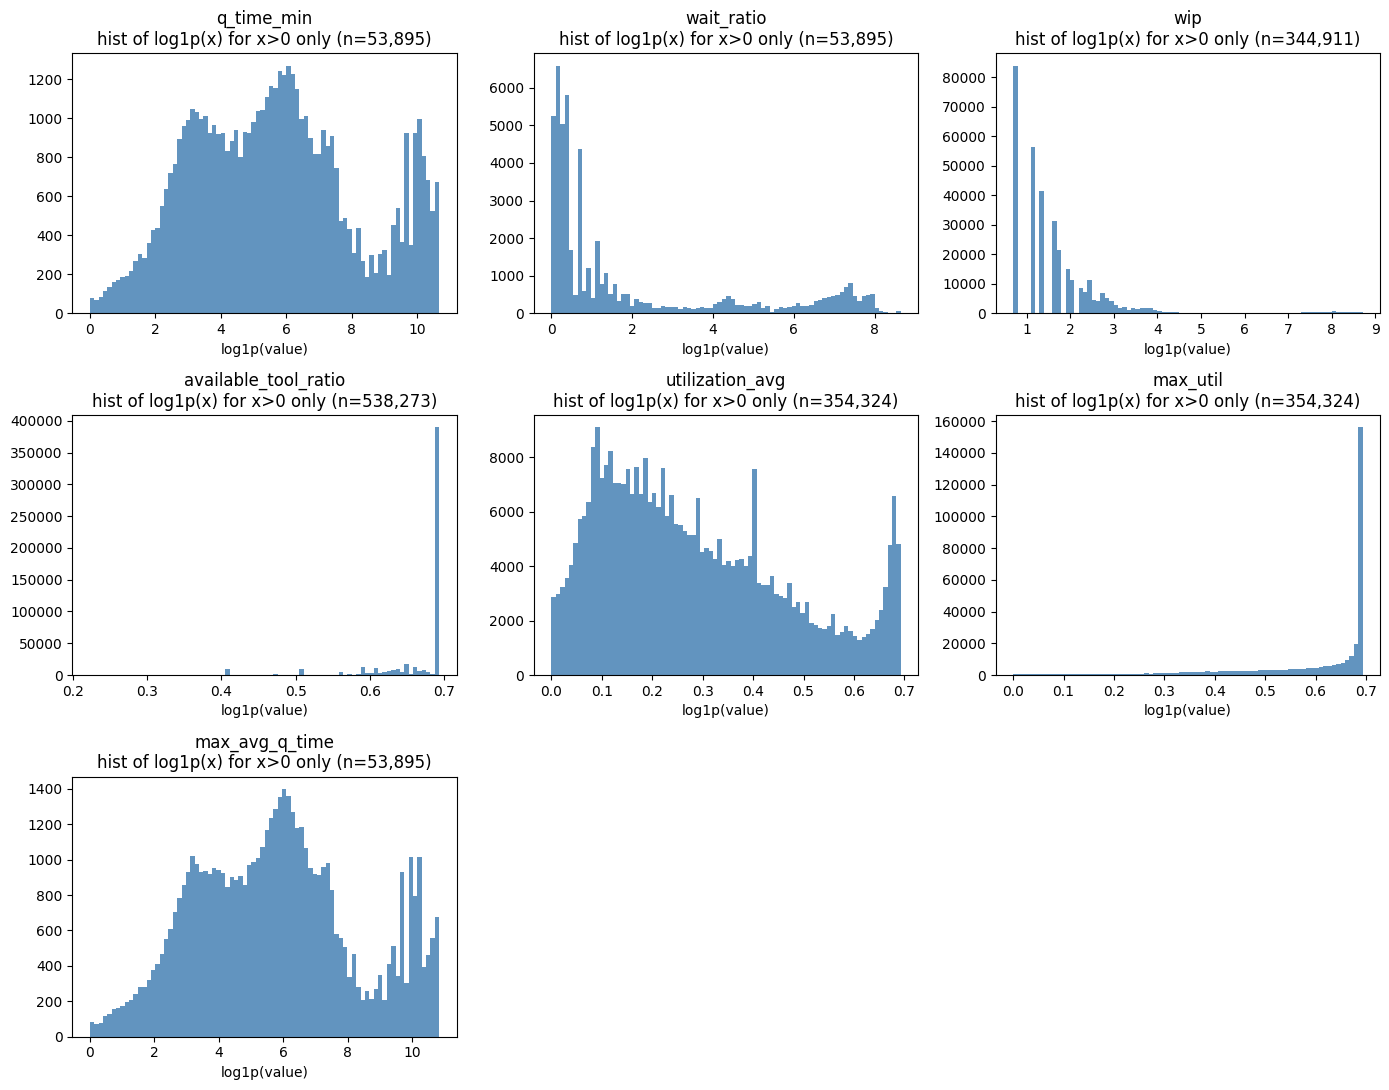

/var/folders/p7/97j17x997kv55r8_m3cjpc340000gn/T/ipykernel_84378/1356752749.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([Z[c].dropna() for c in EDA_COLS], labels=EDA_COLS, showfliers=False)


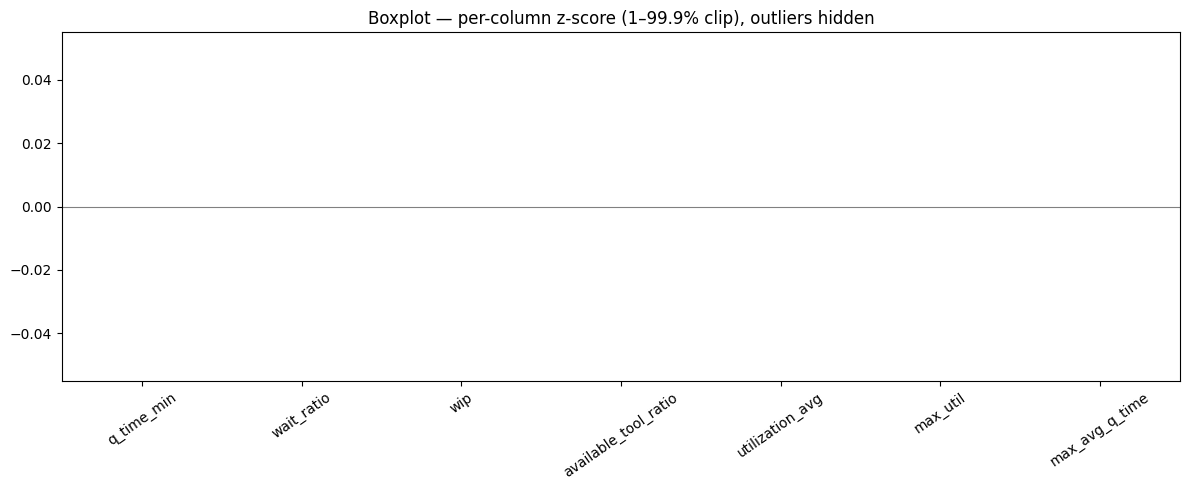

/var/folders/p7/97j17x997kv55r8_m3cjpc340000gn/T/ipykernel_84378/1356752749.py:65: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p7/97j17x997kv55r8_m3cjpc340000gn/T/ipykernel_84378/1356752749.py:65: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p7/97j17x997kv55r8_m3cjpc340000gn/T/ipykernel_84378/1356752749.py:65: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p7/97j17x997kv55r8_m3cjpc340000gn/T/ipykernel_84378/1356752749.py:65: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p7/97j17x997kv55r8_m3cjpc340000gn/T/ipykernel_84378/1356752749.py:65: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/skala/Desktop/SKALA/Final_Project/FAB_BEAR/simula

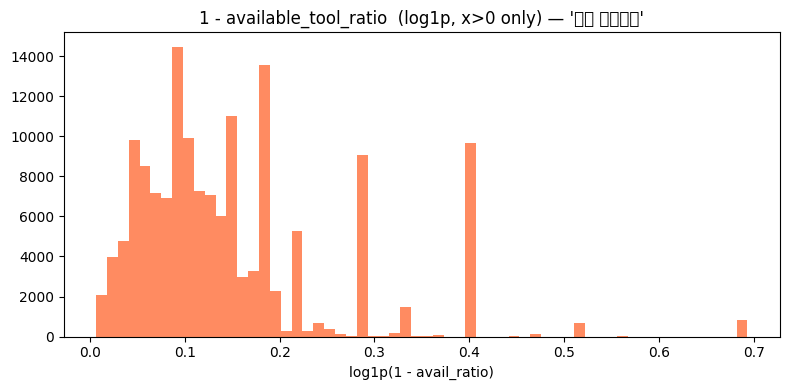

In [12]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# wide 가 없으면 위 셀부터 실행
assert "wide" in dir() and isinstance(wide, pd.DataFrame), "먼저 wide DataFrame 을 만드세요."

EDA_COLS = [
    "q_time_min",
    "wait_ratio",
    "wip",
    "available_tool_ratio",  # low_avail 규칙: 이 값이 낮을수록 나쁨
    "utilization_avg",
    "max_util",
    "max_avg_q_time",
]
missing = [c for c in EDA_COLS if c not in wide.columns]
if missing:
    raise ValueError(f"wide 에 없는 컬럼: {missing}")

X = wide[EDA_COLS].apply(pd.to_numeric, errors="coerce")

# 요약 통계 (NaN 제외)
desc = X.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
desc["zeros_pct"] = (X == 0).mean() * 100
desc["neg_count"] = (X < 0).sum()
display(desc.round(4))

# 히스토그램 (log1p: 0 많고 꼬리 긴 변수용)
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.ravel()
for ax, col in zip(axes, EDA_COLS):
    s = X[col].dropna()
    s_pos = s[s > 0]
    if len(s_pos) > 0:
        ax.hist(np.log1p(s_pos), bins=80, color="steelblue", alpha=0.85, edgecolor="none")
        ax.set_title(f"{col}\nhist of log1p(x) for x>0 only (n={len(s_pos):,})")
        ax.set_xlabel("log1p(value)")
    else:
        ax.text(0.5, 0.5, "no positive values", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(col)
for j in range(len(EDA_COLS), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

# 박스플롯 (표준화해서 스케일 비교)
Z = (X - X.mean()) / X.std(ddof=0).replace(0, np.nan)
Z = Z.clip(lower=Z.quantile(0.001), upper=Z.quantile(0.999), axis=0)

fig2, ax2 = plt.subplots(figsize=(12, 5))
ax2.boxplot([Z[c].dropna() for c in EDA_COLS], labels=EDA_COLS, showfliers=False)
ax2.set_title("Boxplot — per-column z-score (1–99.9% clip), outliers hidden")
ax2.tick_params(axis="x", rotation=35)
ax2.axhline(0, color="gray", lw=0.8)
plt.tight_layout()
plt.show()

# 가용 '나쁨' 관점: 1 - available_tool_ratio
low_stress = (1.0 - X["available_tool_ratio"]).clip(lower=0, upper=1)
fig3, ax3 = plt.subplots(figsize=(8, 4))
ax3.hist(np.log1p(low_stress[low_stress > 0]), bins=60, color="coral", alpha=0.9, edgecolor="none")
ax3.set_title("1 - available_tool_ratio  (log1p, x>0 only) — '가용 스트레스'")
ax3.set_xlabel("log1p(1 - avail_ratio)")
plt.tight_layout()
plt.show()

## 6) 분위수 기반 weak label (조정 가능)

아래 **`PERCENTILE_LABEL_RULES`** 만 수정하면 임계 분위를 바꿀 수 있습니다.

- **`upper`**: `값 > ref의 q 분위수` 이면 해당 조건 True (예: 상위 5% ≈ q=0.95, **엄격한 초과**)
- **`lower`**: `값 < ref의 q 분위수` 이면 True (예: 하위 1% ≈ q=0.01)

최종 라벨 **`y_bottleneck_pct`** = 조건 중 **하나라도** True 이면 1 (OR). `combine="any"` 로 변경 가능.

**누수 주의:** 기본은 `wide` 전체로 분위를 잡습니다. train/valid 분리 시에는 **`ref_df=train_wide`** 로만 분위를 계산하세요.

In [19]:
from __future__ import annotations

from typing import Literal

# ---------------------------------------------------------------------------
# 향후 조정: (컬럼명, "upper"|"lower", 분위 q in (0,1))
#  - upper: 병목 후보로 "크면 나쁨" → 값 > ref.quantile(q)
#  - lower: "작으면 나쁨" (가용) → 값 < ref.quantile(q)
# ---------------------------------------------------------------------------
PERCENTILE_LABEL_RULES: dict[str, tuple[Literal["upper", "lower"], float]] = {
    "q_time_min": ("upper", 0.95),
    "wait_ratio": ("upper", 0.95),
    "wip": ("upper", 0.95),
    "available_tool_ratio": ("lower", 0.01),
    "utilization_avg": ("upper", 0.95),
    "max_util": ("upper", 0.75),
    "max_avg_q_time": ("upper", 0.95),
}

# OR: 하나라도 True → 1 | AND: 모두 True → 1
LABEL_COMBINE: Literal["any", "all"] = "any"


def compute_percentile_thresholds(
    ref: pd.DataFrame,
    rules: dict[str, tuple[Literal["upper", "lower"], float]],
) -> pd.Series:
    """컬럼별 분위 임계값 (Series index = 컬럼명)."""
    out: dict[str, float] = {}
    for col, (_tail, q) in rules.items():
        if col not in ref.columns:
            raise KeyError(f"ref 에 컬럼 없음: {col}")
        if not 0 < q < 1:
            raise ValueError(f"{col}: q 는 (0,1) 이어야 함, got {q}")
        s = pd.to_numeric(ref[col], errors="coerce").dropna()
        if s.empty:
            raise ValueError(f"{col}: 유효 값이 없음")
        out[col] = float(s.quantile(q))
    return pd.Series(out, name="threshold")


def assign_percentile_bottleneck_labels(
    df: pd.DataFrame,
    rules: dict[str, tuple[Literal["upper", "lower"], float]],
    *,
    ref_df: pd.DataFrame | None = None,
    combine: Literal["any", "all"] = "any",
    label_col: str = "y_bottleneck_pct",
    prefix_flag: str = "flag_pct__",
) -> pd.DataFrame:
    """
    ref_df 가 None 이면 df 와 동일 데이터로 분위 계산 (EDA/실험용, 학습 누수 가능).
    """
    ref = df if ref_df is None else ref_df
    thr = compute_percentile_thresholds(ref, rules)
    out = df.copy()
    flags = []
    for col, (tail, _q) in rules.items():
        v = pd.to_numeric(out[col], errors="coerce")
        t = thr[col]
        if tail == "upper":
            f = v > t
        else:
            f = v < t
        name = f"{prefix_flag}{col}"
        out[name] = f.fillna(False)
        flags.append(out[name])
    mat = pd.concat(flags, axis=1)
    if combine == "any":
        out[label_col] = mat.any(axis=1).astype("int8")
    else:
        out[label_col] = mat.all(axis=1).astype("int8")
    return out


assert "wide" in dir() and isinstance(wide, pd.DataFrame)

pct_thresholds = compute_percentile_thresholds(wide, PERCENTILE_LABEL_RULES)
display(pct_thresholds.to_frame("threshold").round(6))

wide_labeled = assign_percentile_bottleneck_labels(
    wide,
    PERCENTILE_LABEL_RULES,
    ref_df=None,
    combine=LABEL_COMBINE,
)

pos = wide_labeled["y_bottleneck_pct"].mean() * 100
print(f"y_bottleneck_pct positive rate: {pos:.2f}%")
print("per-flag rate (% of rows):")
flag_cols = [c for c in wide_labeled.columns if c.startswith("flag_pct__")]
display(wide_labeled[flag_cols].mean().mul(100).round(3).sort_values(ascending=False))

wide_labeled[["snapshot_time", "toolgroup", "y_bottleneck_pct"] + flag_cols[:3]].head(8)

,threshold
q_time_min,255.427245
wait_ratio,1.000000
wip,24.000000
available_tool_ratio,0.500000
utilization_avg,0.866155
max_util,0.995308
max_avg_q_time,305.446759


y_bottleneck_pct positive rate: 31.42%
per-flag rate (% of rows):


kpi_name
flag_pct__max_util                25.000
flag_pct__q_time_min               5.000
flag_pct__utilization_avg          5.000
flag_pct__max_avg_q_time           5.000
flag_pct__wip                      4.941
flag_pct__wait_ratio               4.572
flag_pct__available_tool_ratio     0.312
dtype: float64

kpi_name,snapshot_time,toolgroup,y_bottleneck_pct,flag_pct__q_time_min,flag_pct__wait_ratio,flag_pct__wip
0,60.0,DE_BE_11,0,False,False,False
1,60.0,DE_BE_12,0,False,False,False
2,60.0,DE_BE_13,0,False,False,False
3,60.0,DE_BE_48,0,False,False,False
4,60.0,DE_BE_50,0,False,False,False
5,60.0,DE_BE_65,0,False,False,False
6,60.0,DE_BE_66,0,False,False,False
7,60.0,DE_BE_67,0,False,False,False


## 7) REPORT 규칙 + **H=120** lookahead — `y_bottleneck`

- **입력(X):** `wide`의 **t 시점** KPI (merge 후 왼쪽 컬럼).
- **라벨(y):** 같은 TG의 **t+120분** KPI에 `REPORT_SIMULATION_KPI.md` 부등식 적용.
- **drop:** `inner` merge로 **t+120 스냅이 없는 행** 제거 (60분 격자면 대략 **2×TG 수** 행).

```text
y = 1 if
  (q_time_min >= Q and (wait_ratio >= W or wip >= N))
  or (available_tool_ratio <= A)
  or (max_util >= U_hi and utilization_avg < U_lo)
  or (max_avg_q_time >= Q and wait_ratio >= W)
```

아래 **`Q_THR` … `U_LO`** 만 조정하면 됩니다.

In [24]:
LOOKAHEAD_MIN = 120.0  # H = 2h (스냅 60분이면 정확히 +2 스텝)

# §6 분위수 threshold를 §7 REPORT 임계값으로 자동 매핑
AUTO_THR_FROM_PCT = True

LABEL_KPI_COLS = [
    "q_time_min",
    "wait_ratio",
    "wip",
    "available_tool_ratio",
    "utilization_avg",
    "max_util",
    "max_avg_q_time",
]

if AUTO_THR_FROM_PCT:
    # 1) §6 결과 재사용 (권장)
    if "pct_thresholds" in dir():
        thr = pct_thresholds
    # 2) §6 함수가 있으면 즉시 재계산
    elif "compute_percentile_thresholds" in dir() and "PERCENTILE_LABEL_RULES" in dir():
        thr = compute_percentile_thresholds(wide, PERCENTILE_LABEL_RULES)
    # 3) 최소 fallback: 기본 분위 규칙으로 현 셀에서 계산
    else:
        rules = {
            "q_time_min": ("upper", 0.95),
            "wait_ratio": ("upper", 0.95),
            "wip": ("upper", 0.95),
            "available_tool_ratio": ("lower", 0.01),
            "utilization_avg": ("upper", 0.95),
            "max_util": ("upper", 0.75),
            "max_avg_q_time": ("upper", 0.95),
        }
        vals = {}
        for col, (tail, q) in rules.items():
            s = pd.to_numeric(wide[col], errors="coerce")
            vals[col] = s.quantile(q)
        thr = pd.Series(vals)

    # §6 threshold -> §7 parameter 매핑
    Q_THR = float(thr["q_time_min"])
    W_THR = float(thr["wait_ratio"])
    WIP_THR = float(thr["wip"])
    AVAIL_THR = float(thr["available_tool_ratio"])
    U_HI = float(thr["max_util"])
    U_LO = float(thr["utilization_avg"])

    print("[AUTO] REPORT thresholds from percentile table")
    print(
        f"Q={Q_THR:.6f}, W={W_THR:.6f}, WIP={WIP_THR:.6f}, "
        f"A={AVAIL_THR:.6f}, U_HI={U_HI:.6f}, U_LO={U_LO:.6f}"
    )


def attach_future_labels_tg(
    df: pd.DataFrame,
    horizon: float,
    label_cols: list[str],
) -> pd.DataFrame:
    """t 행에 t+H KPI 붙임. `run_id` 컬럼이 있으면 조인 키에 포함."""
    keys = ["run_id", "snapshot_time", "toolgroup"] if "run_id" in df.columns else ["snapshot_time", "toolgroup"]
    miss = [c for c in label_cols if c not in df.columns]
    if miss:
        raise KeyError(miss)
    future = df[[*keys, *label_cols]].copy()
    future = future.rename(columns={c: f"{c}_future" for c in label_cols})
    future["snapshot_time"] = future["snapshot_time"] - horizon
    return df.merge(future, on=keys, how="inner")


def assign_y_bottleneck_report(
    df: pd.DataFrame,
    *,
    q_thr: float,
    w_thr: float,
    wip_thr: float,
    avail_thr: float,
    u_hi: float,
    u_lo: float,
) -> pd.Series:
    """부등식은 전부 t+H 값 (*_future)."""
    q = df["q_time_min_future"].fillna(0)
    w = df["wait_ratio_future"].fillna(0)
    wip = df["wip_future"].fillna(0)
    avail = df["available_tool_ratio_future"].fillna(0)
    util_avg = df["utilization_avg_future"].fillna(0)
    max_util = df["max_util_future"].fillna(0)
    max_q = df["max_avg_q_time_future"].fillna(0)

    tg_congestion = (q >= q_thr) & ((w >= w_thr) | (wip >= wip_thr))
    low_avail = avail <= avail_thr
    hot_spot_util = (max_util >= u_hi) & (util_avg < u_lo)
    hot_spot_queue = (max_q >= q_thr) & (w >= w_thr)

    y = tg_congestion | low_avail | hot_spot_util | hot_spot_queue
    return y.astype("int8")


assert "wide" in dir() and isinstance(wide, pd.DataFrame)

n_before = len(wide)
n_tg = wide["toolgroup"].nunique()

wide_train = attach_future_labels_tg(wide, LOOKAHEAD_MIN, LABEL_KPI_COLS)
n_after = len(wide_train)
dropped = n_before - n_after

print(f"wide rows: {n_before:,}")
print(f"after inner merge (need t+{LOOKAHEAD_MIN:.0f}): {n_after:,}  (dropped {dropped:,})")
print(f"n_toolgroups={n_tg} → expected drop ≈ 2 × n_tg = {2 * n_tg}")

wide_train["y_bottleneck"] = assign_y_bottleneck_report(
    wide_train,
    q_thr=Q_THR,
    w_thr=W_THR,
    wip_thr=WIP_THR,
    avail_thr=AVAIL_THR,
    u_hi=U_HI,
    u_lo=U_LO,
)

pos = wide_train["y_bottleneck"].sum()
print(
    f"y_bottleneck positive: {int(pos):,} / {len(wide_train):,} "
    f"({100 * pos / len(wide_train):.2f}%)"
)

#wide_train[["snapshot_time", "toolgroup", "y_bottleneck", "q_time_min", "wait_ratio"]].head(10)

[AUTO] REPORT thresholds from percentile table
Q=255.427245, W=1.000000, WIP=24.000000, A=0.500000, U_HI=0.995308, U_LO=0.866155
wide rows: 539,116
after inner merge (need t+120): 538,904  (dropped 212)
n_toolgroups=106 → expected drop ≈ 2 × n_tg = 212
y_bottleneck positive: 153,895 / 538,904 (28.56%)


In [25]:
wide_train

kpi_name,snapshot_time,toolgroup,available_tool_ratio,q_time_min,wait_ratio,wip,setup_ratio_avg,utilization_avg,max_avg_q_time,max_util,q_time_min_future,wait_ratio_future,wip_future,available_tool_ratio_future,utilization_avg_future,max_util_future,max_avg_q_time_future,y_bottleneck
0,60.0,DE_BE_11,1.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0
1,60.0,DE_BE_12,1.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0
2,60.0,DE_BE_13,1.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0
3,60.0,DE_BE_48,1.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0
4,60.0,DE_BE_50,1.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
538899,305040.0,WE_FE_47,1.000000,0.0,0.0,2.0,0.0,0.305253,0.0,0.762703,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0
538900,305040.0,WE_FE_8,1.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,2.0,1.000000,0.965813,0.977804,0.000000,0
538901,305040.0,WE_FE_83,1.000000,0.0,0.0,4.0,0.0,0.197593,0.0,0.822037,0.218798,0.142857,8.0,1.000000,0.549197,0.790600,0.218798,0
538902,305040.0,WE_FE_84,0.947368,0.0,0.0,8.0,0.0,0.413716,0.0,0.925625,0.000000,0.000000,5.0,0.947368,0.259609,0.875140,0.000000,0


## 8) XGBoost — 학습 / 검증 / 평가 **70 : 15 : 15**

- **피처:** 시각 **t** 의 수치 KPI만 (`*_future`·`y_bottleneck`·**`snapshot_time`** 제외). `toolgroup` 은 `LabelEncoder`.
  - `snapshot_time` 은 pivot/lookahead **키**로만 쓰고, 모델 입력에서는 제외 (시뮬 후반일수록 병목↑ 같은 **시간 누수** 방지).
- **분할:** `snapshot_time` **고유 시각** 기준 **시간 순** 70% · 15% · 15% (train → val → test). `train_test_split(shuffle)` **사용 안 함**.
- **설치:** `pip install xgboost scikit-learn` (FAB_BEAR simulation 커널)

In [27]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.preprocessing import LabelEncoder

try:
    from xgboost import XGBClassifier
except ImportError as e:
    raise ImportError("pip install xgboost") from e

assert "wide_train" in dir() and "y_bottleneck" in wide_train.columns, (
    "먼저 섹션 7까지 실행해 wide_train 과 y_bottleneck 을 만드세요."
)

RANDOM_STATE = 42
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15

EXCLUDE_SUBSTR = ("_future",)
# snapshot_time: pivot/label 키만 — 모델 feature 아님 (시뮬 경과 시간 누수)
EXCLUDE_NAMES = {"y_bottleneck", "run_id", "snapshot_time"}

num_cols = [
    c
    for c in wide_train.columns
    if c not in EXCLUDE_NAMES
    and c != "toolgroup"
    and not any(s in c for s in EXCLUDE_SUBSTR)
    and pd.api.types.is_numeric_dtype(wide_train[c])
]

df_ml = wide_train[["snapshot_time", "toolgroup", *num_cols, "y_bottleneck"]].copy()
df_ml[num_cols] = df_ml[num_cols].apply(pd.to_numeric, errors="coerce")

le_tg = LabelEncoder()
df_ml["toolgroup_enc"] = le_tg.fit_transform(df_ml["toolgroup"].astype(str))

FEATURE_COLS = num_cols + ["toolgroup_enc"]


def temporal_split_by_snapshot_time(
    df: pd.DataFrame,
    *,
    train_frac: float = 0.70,
    val_frac: float = 0.15,
    test_frac: float = 0.15,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Split by unique snapshot_time (ascending). All TG rows at time t stay in one fold."""
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6
    times = np.sort(df["snapshot_time"].astype(float).unique())
    n_t = len(times)
    i_train_end = int(n_t * train_frac)
    i_val_end = int(n_t * (train_frac + val_frac))
    i_train_end = max(1, min(i_train_end, n_t - 2))
    i_val_end = max(i_train_end + 1, min(i_val_end, n_t - 1))

    t_train_max = times[i_train_end - 1]
    t_val_max = times[i_val_end - 1]

    train = df[df["snapshot_time"] <= t_train_max]
    val = df[(df["snapshot_time"] > t_train_max) & (df["snapshot_time"] <= t_val_max)]
    test = df[df["snapshot_time"] > t_val_max]
    return train, val, test


df_train, df_val, df_test = temporal_split_by_snapshot_time(
    df_ml, train_frac=TRAIN_FRAC, val_frac=VAL_FRAC, test_frac=TEST_FRAC
)

X_train = df_train[FEATURE_COLS].fillna(0.0)
X_val = df_val[FEATURE_COLS].fillna(0.0)
X_test = df_test[FEATURE_COLS].fillna(0.0)
y_train = df_train["y_bottleneck"].astype(int).values
y_val = df_val["y_bottleneck"].astype(int).values
y_test = df_test["y_bottleneck"].astype(int).values

n = len(df_ml)
print("n=", n, " n_features=", len(FEATURE_COLS), " pos_rate=", round(df_ml["y_bottleneck"].mean() * 100, 2), "%")
print(
    "sizes train/val/test:",
    len(X_train),
    len(X_val),
    len(X_test),
    " fractions:",
    round(len(X_train) / n, 4),
    round(len(X_val) / n, 4),
    round(len(X_test) / n, 4),
)
for name, part in [("train", df_train), ("val", df_val), ("test", df_test)]:
  tmin, tmax = part["snapshot_time"].min(), part["snapshot_time"].max()
  print(f"  {name} snapshot_time: {tmin:.0f} → {tmax:.0f}  pos_rate={part['y_bottleneck'].mean()*100:.2f}%")

scale_pos_weight = float((y_train == 0).sum() / max(1, (y_train == 1).sum()))

model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.06,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)


n= 538904  n_features= 9  pos_rate= 28.56 %
sizes train/val/test: 377148 80878 80878  fractions: 0.6998 0.1501 0.1501
  train snapshot_time: 60 → 213480  pos_rate=27.76%
  val snapshot_time: 213540 → 259260  pos_rate=30.65%
  test snapshot_time: 259320 → 305040  pos_rate=30.20%
[0]	validation_0-logloss:0.66173
[50]	validation_0-logloss:0.30406
[100]	validation_0-logloss:0.28874
[150]	validation_0-logloss:0.28276
[200]	validation_0-logloss:0.28050
[250]	validation_0-logloss:0.27932
[300]	validation_0-logloss:0.27872
[350]	validation_0-logloss:0.27829
[400]	validation_0-logloss:0.27799
[450]	validation_0-logloss:0.27795
[499]	validation_0-logloss:0.27794


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.85
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [33]:
def _report(split_name: str, Xs, ys) -> None:
    proba = model.predict_proba(Xs)[:, 1]
    pred = (proba >= 0.9).astype(int)
    print("\n===", split_name, "===")
    print("accuracy:", round(accuracy_score(ys, pred), 4))
    if len(set(ys)) > 1:
        print("roc_auc:", round(roc_auc_score(ys, proba), 4))
    print("confusion_matrix [ [TN FP] [FN TP] ]:")
    print(confusion_matrix(ys, pred))
    print(classification_report(ys, pred, digits=4))


#_report("validation", X_val, y_val) 
_report("test (hold-out)", X_test, y_test)

imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
display(imp.head(20).to_frame("importance"))


=== test (hold-out) ===
accuracy: 0.8613
roc_auc: 0.955
confusion_matrix [ [TN FP] [FN TP] ]:
[[55399  1057]
 [10160 14262]]
              precision    recall  f1-score   support

           0     0.8450    0.9813    0.9081     56456
           1     0.9310    0.5840    0.7177     24422

    accuracy                         0.8613     80878
   macro avg     0.8880    0.7826    0.8129     80878
weighted avg     0.8710    0.8613    0.8506     80878



,importance
max_util,0.325866
toolgroup_enc,0.174970
wait_ratio,0.144921
wip,0.141111
available_tool_ratio,0.121100
max_avg_q_time,0.041836
utilization_avg,0.026043
q_time_min,0.024155
setup_ratio_avg,0.000000


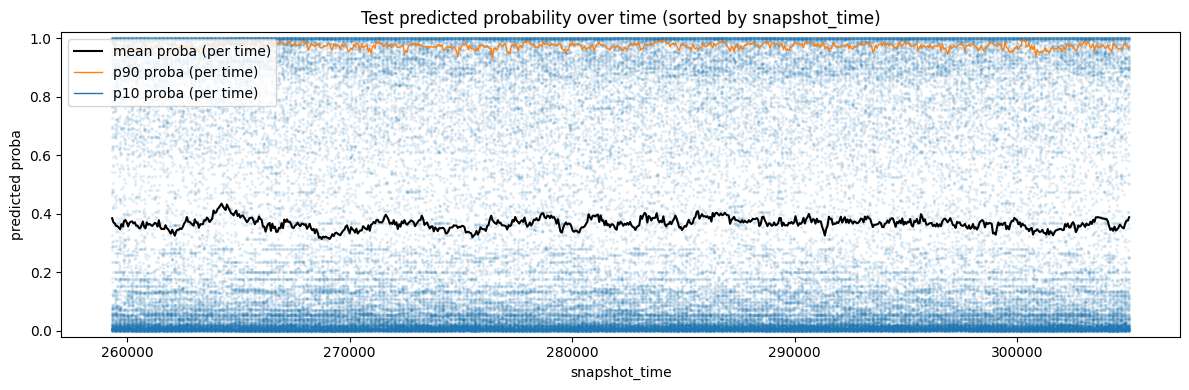

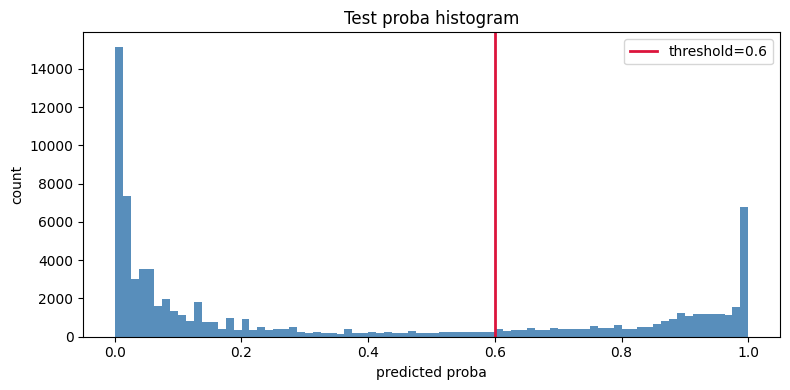

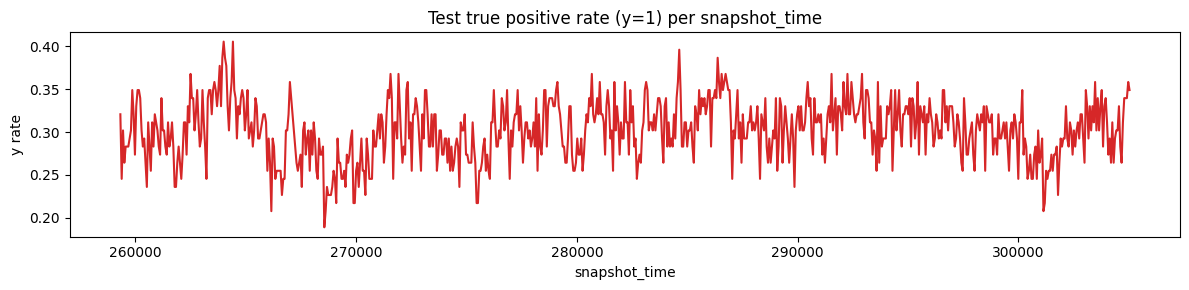

alarms per time (first 10):
snapshot_time
259320.0    39
259380.0    35
259440.0    37
259500.0    36
259560.0    36
259620.0    34
259680.0    33
259740.0    37
259800.0    32
259860.0    36
Name: alarm, dtype: int64
mean alarms per time: 35.980340760157276


In [31]:
# (추가) Test 구간에서 시간 순서로 예측확률 분포 확인
# - df_test에는 snapshot_time, toolgroup, y_bottleneck, feature들이 포함되어 있어야 함 (sec8 셀 실행 후)

import matplotlib.pyplot as plt

assert "df_test" in dir() and "X_test" in dir() and "y_test" in dir(), "먼저 §8 셀을 실행하세요."

proba_test = model.predict_proba(X_test)[:, 1]
plot_df = df_test[["snapshot_time", "toolgroup", "y_bottleneck"]].copy()
plot_df["proba"] = proba_test
plot_df = plot_df.sort_values(["snapshot_time", "toolgroup"]).reset_index(drop=True)

# 1) 시간축 scatter + time별 요약선
fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(plot_df["snapshot_time"], plot_df["proba"], s=2, alpha=0.08)

by_t = plot_df.groupby("snapshot_time", as_index=False).agg(
    proba_mean=("proba", "mean"),
    proba_p90=("proba", lambda s: s.quantile(0.90)),
    proba_p10=("proba", lambda s: s.quantile(0.10)),
    y_rate=("y_bottleneck", "mean"),
)
ax.plot(by_t["snapshot_time"], by_t["proba_mean"], color="black", lw=1.5, label="mean proba (per time)")
ax.plot(by_t["snapshot_time"], by_t["proba_p90"], color="tab:orange", lw=1.0, label="p90 proba (per time)")
ax.plot(by_t["snapshot_time"], by_t["proba_p10"], color="tab:blue", lw=1.0, label="p10 proba (per time)")
ax.set_title("Test predicted probability over time (sorted by snapshot_time)")
ax.set_xlabel("snapshot_time")
ax.set_ylabel("predicted proba")
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

# 2) 분포(히스토그램) + 임계값 표시
THR = 0.6  # 운영 threshold 후보
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.hist(plot_df["proba"], bins=80, alpha=0.9, color="steelblue", edgecolor="none")
ax2.axvline(THR, color="crimson", lw=2, label=f"threshold={THR}")
ax2.set_title("Test proba histogram")
ax2.set_xlabel("predicted proba")
ax2.set_ylabel("count")
ax2.legend()
plt.tight_layout()
plt.show()

# 3) 시간별 true 양성률(y)과 proba 평균 비교
fig3, ax3 = plt.subplots(figsize=(12, 3))
ax3.plot(by_t["snapshot_time"], by_t["y_rate"], color="tab:red", lw=1.5)
ax3.set_title("Test true positive rate (y=1) per snapshot_time")
ax3.set_xlabel("snapshot_time")
ax3.set_ylabel("y rate")
plt.tight_layout()
plt.show()

# 4) 시간별 알람 개수(=민감도) 확인
alarm_by_t = plot_df.assign(alarm=(plot_df["proba"] >= THR).astype(int)).groupby("snapshot_time")["alarm"].sum()
print("alarms per time (first 10):")
print(alarm_by_t.head(10))
print("mean alarms per time:", float(alarm_by_t.mean()))
